# Pharm medication adherence package tutorial

In [14]:
# import the packages we created - model trainer and dataset classes
from src.pharma_adherence.data import PharmaDataset
from src.pharma_adherence.modeling import ModelTrainer

### Initialize the dataset

In [15]:
# Initialize the dataset with path to the raw data
dataset = PharmaDataset("data/raw/prescriptions_large_raw.csv")

### Data cleaning
We need to clean our data so that it is in a format that can be used for modeling. This includes cleaning text data, converting data types, and creating new features. We will use the clean function from the pharmadataset class to clean our data and put it in a new csv file.

In [16]:
dataset.clean()
dataset.save("data/processed/prescriptions_large_cleaned.csv")

/Users/ashleyjung/Desktop/cdd209-final-template/src/pharma_adherence/cleaning.py:45: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["patient_id"] = _clean_text_series(df["patient_id"]).str.upper()
/Users/ashleyjung/Desktop/cdd209-final-tem

### Showing the cleaned data
We can show the cleaned data against various fields to see if there are any trends in the data. We can use the hist, bar, and scatter functions from the PharmaDataset class to visualize the data.

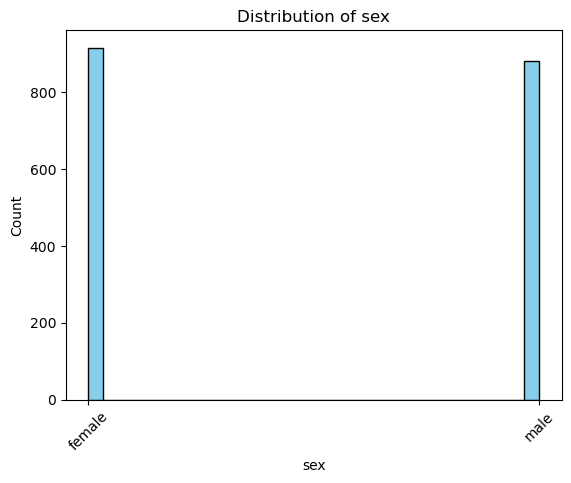

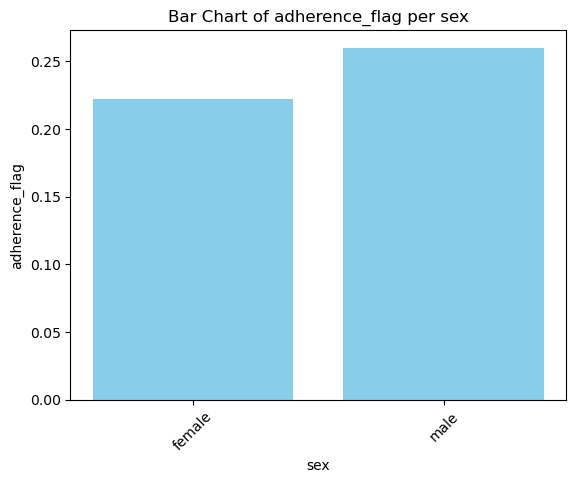

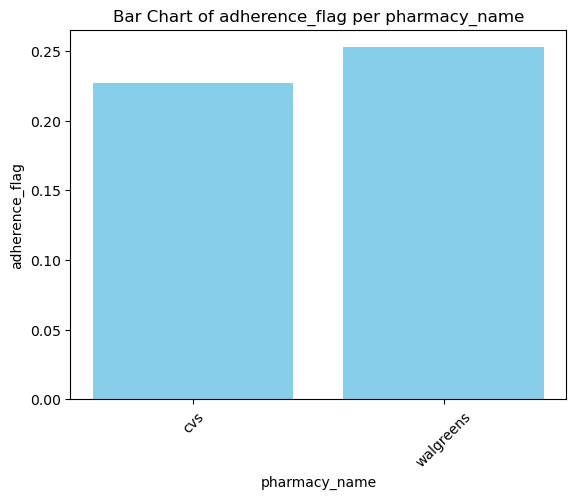

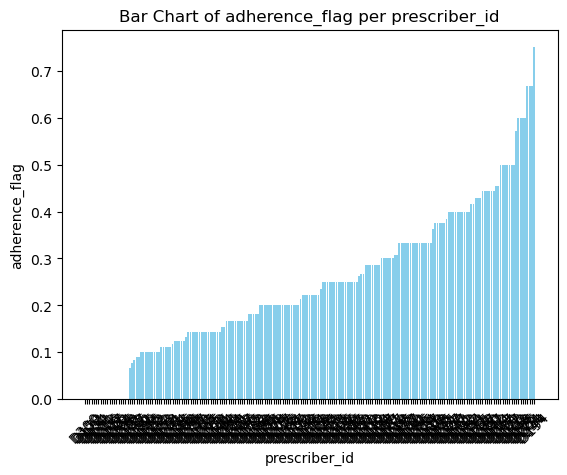

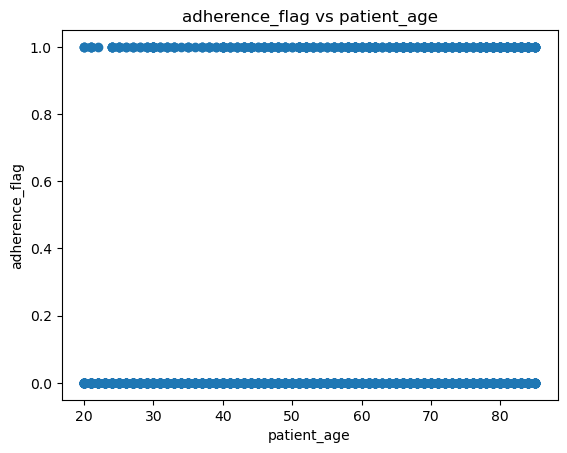

In [22]:
dataset.hist("sex").show()
dataset.bar("sex", "adherence_flag").show()
dataset.bar("pharmacy_name", "adherence_flag").show()
dataset.bar("prescriber_id", "adherence_flag").show()
dataset.scatter("patient_age", "adherence_flag").show()

## Interpreting Results

We can see the different trends in the data and understand how different features are related to adherence. For example, we can see that female patients are more likely to be adherent than male patients. We can also see that different prescribers may have varying impacts on patient adherence.

In [10]:
#We can also look at the summary of a patient to see what the data looks like for a single patient
patient = dataset.get_patient("P057")
print(patient.summary())

{'patient_id': 'P057', 'total_fills': 5, 'avg_copay': np.float64(17.419999999999998), 'avg_days_supply': np.float64(60.0), 'pdc': np.float64(0.608), 'adherent': np.False_}


# Machine Learning

## Linear Regression: Initializing the model and training it

In [ ]:
# Create a linear regression trainer
linear_model = ModelTrainer(dataset.df, target="proportion_days_covered", features=["sex", "copay_amount"])

# Train the linear model
model, metrics = linear_model.train_linear()

# Print the linear model metrics
print(metrics)

{'mse': 0.004902786305147368, 'mae': 0.05588585767712229, 'r2': 0.6093843103664952}


## Logistic Regression: Initializing the model and training it

In [ ]:
# Create a logistic regression trainer
logistic_model = ModelTrainer(dataset.df, "adherence_flag", ["sex", "copay_amount"])

# Train the logistic model
model, metrics = logistic_model.train_logistic()

# Print the logistic model metrics
print (metrics)


{'accuracy': 0.7916666666666666, 'precision': 0.6111111111111112, 'recall': 0.5789473684210527, 'roc_auc': 0.8503872889771599}


You can see the accuracy of the model and various metrics such as precision, recall, and roc_auc.

### How Different Features Affect Adherence

In [21]:
logistic_model = ModelTrainer(dataset.df, "adherence_flag", ["pharmacy_name", "prescriber_id", "proportion_days_covered", "copay_amount"])
model, metrics = logistic_model.train_logistic()
print (metrics)

{'accuracy': 0.8638888888888889, 'precision': 0.7674418604651163, 'recall': 0.6947368421052632, 'roc_auc': 0.9310029791459782}


### Interpreting Results

We can see the accuracy and precision of the model to see how well our model is performing. We can also see that adding more features to the model can improve the performance of the model.